In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import cv2

In [2]:
DATA_ROOT = Path('../data/FungiTastic')

mask_path = DATA_ROOT / 'FungiTastic-Mini-TrainMasks.parquet'
df_path = DATA_ROOT / 'metadata' / 'FungiTastic-Mini' / 'FungiTastic-Mini-Train.csv'

df = pd.read_csv(df_path)
df["image_path"] = df.filename.apply(
  lambda x: str((DATA_ROOT / 'FungiTastic' / 'train' / '300p' / x).resolve())
)

gt_masks = pd.read_parquet(mask_path)
gt_masks.rename(columns={'file_name': 'filename'}, inplace=True)


df = df.merge(gt_masks, on='filename', how='inner')


In [3]:
print(df.columns.tolist())

['eventDate', 'year', 'month', 'day', 'habitat', 'countryCode', 'scientificName', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'specificEpithet', 'hasCoordinate', 'species', 'iucnRedListCategory', 'substrate', 'latitude', 'longitude', 'coorUncert', 'observationID', 'region', 'district', 'filename', 'category_id', 'metaSubstrate', 'poisonous', 'elevation', 'landcover', 'biogeographicalRegion', 'captions', 'image_path', 'label', 'width', 'height', 'rle']


In [ ]:

# print(df.head())
# print(gt_masks.head())
print('---')
print(df[['filename', 'rle', 'width', 'height', 'label']].sample())
print(df.loc[df['filename'] == "0-3036761318.JPG"])

---
               filename                                                rle  \
24881  0-3419915381.JPG  [368871, 17, 34, 22, 1583, 24, 23, 31, 1578, 3...   

       width  height label  
24881   1658    1200   cap  
    eventDate  year  month  day             habitat countryCode  \
0  2008-09-01  2008    9.0  1.0  Deciduous woodland          DK   
1  2008-09-01  2008    9.0  1.0  Deciduous woodland          DK   
2  2008-09-01  2008    9.0  1.0  Deciduous woodland          DK   
3  2008-09-01  2008    9.0  1.0  Deciduous woodland          DK   
4  2008-09-01  2008    9.0  1.0  Deciduous woodland          DK   
5  2008-09-01  2008    9.0  1.0  Deciduous woodland          DK   

                       scientificName kingdom         phylum           class  \
0  Russula cyanoxantha (Schaeff.) Fr.   Fungi  Basidiomycota  Agaricomycetes   
1  Russula cyanoxantha (Schaeff.) Fr.   Fungi  Basidiomycota  Agaricomycetes   
2  Russula cyanoxantha (Schaeff.) Fr.   Fungi  Basidiomycota  Agaricomy

image.size=(300, 217)
cap [np.int64(253995), np.int64(16), np.int64(1639), np.int64(23), np.int64(1633), np.int64(28), np.int64(1628), np.int64(31), np.int64(1623), np.int64(36), np.int64(1618), np.int64(41), np.int64(1613), np.int64(45), np.int64(1609), np.int64(50), np.int64(1605), np.int64(54), np.int64(1602), np.int64(57), np.int64(1599), np.int64(60), np.int64(1596), np.int64(62), np.int64(1594), np.int64(65), np.int64(1592), np.int64(66), np.int64(1590), np.int64(69), np.int64(1587), np.int64(72), np.int64(1585), np.int64(74), np.int64(1583), np.int64(75), np.int64(123), np.int64(9), np.int64(1449), np.int64(78), np.int64(114), np.int64(24), np.int64(1440), np.int64(80), np.int64(110), np.int64(33), np.int64(1434), np.int64(82), np.int64(106), np.int64(39), np.int64(1429), np.int64(85), np.int64(101), np.int64(47), np.int64(1424), np.int64(87), np.int64(95), np.int64(56), np.int64(1419), np.int64(89), np.int64(91), np.int64(62), np.int64(1414), np.int64(92), np.int64(88), np.int6

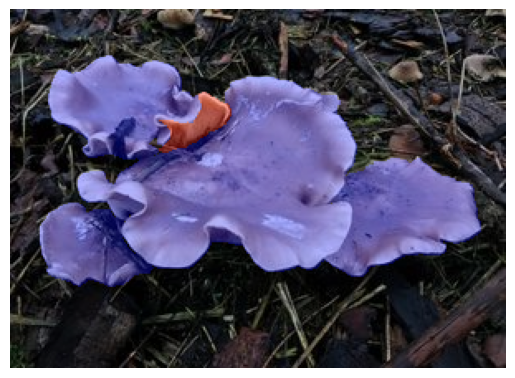

In [40]:
def rle_to_mask(rle_points, height, width):
  mask = np.zeros(height * width, dtype=np.uint8)
  rle_counts = rle_points[:-4]
  current_position = 0
  current_value = 0
  for rle_count in rle_counts:
    mask[current_position:current_position + rle_count] = current_value
    current_value ^= 1
    current_position += rle_count
  mask = mask.reshape((height, width))
  return mask

def visualize_mask(filename):
  rows = df.loc[df['filename'] == filename]

  image_path = rows['image_path'].iloc[0]
  image = Image.open(image_path)

  print(f'{image.size=}')
  
  colors = {
    'gills':         (255, 0, 0),
    'stem':          (0, 255, 0),
    'cap':           (0, 0, 255),
    'ring':          (255, 255, 0),
    'pores':         (255, 0, 255),
    'fruiting_body': (0, 255, 255)
  }
  # colors = {
  #     0: (255, 0, 0),    # gills - red
  #     1: (0, 255, 0),    # stem - green
  #     2: (0, 0, 255),    # cap - blue
  #     3: (255, 255, 0),  # ring - yellow
  #     4: (255, 0, 255),  # pores - magenta
  #     5: (0, 255, 255)   # fruiting_body - cyan
  # }

  width, height = image.size
  overlay = np.zeros((height, width, 3), dtype=np.uint8)
  for row in rows[['rle', 'label', 'width', 'height']].itertuples():
    mask = rle_to_mask(row.rle, row.height, row.width)
    mask = cv2.resize(mask.astype(np.uint8), image.size, interpolation=cv2.INTER_NEAREST).astype(bool)
    if row.label == 'fruiting_body':
      continue
    # print(rle, label, width, height)
    print(row.label, row.rle)
    # plt.imshow(mask)
    # plt.show()
    # plt.imshow(mask, cmap=color[row.label])
    # plt.show()
    # if mask_sum is None:
    #   mask_sum = mask
    # else:
    overlay[mask] = colors[row.label]
    # print(mask_sum.shape, mask.shape)
    # mask_sum |= (2**attribute[row.label]) * mask
  
  image_np = np.array(image)
  blended = cv2.addWeighted(image_np, 0.7, overlay, 0.3, 0)

  plt.imshow(blended)
  plt.axis('off')
  plt.show()
  

# visualize_mask("0-3036761318.JPG")
visualize_mask("0-3419915381.JPG")